# Regenerate HR4000 Figures 4, 9, and 10

This notebook rebuilds the manuscript HR4000 plots from existing saved artifacts, without rerunning simulations.

Outputs:
- `plots/hr4000_with_smd_baseline.pdf` (Figure 4)
- `plots/hr4000_by_voting_rule.pdf` (Figure 9)
- `plots/hr4000_with_size_baseline.pdf` (Figure 10)

In [1]:
import math
import os
import pickle
import sys
from pathlib import Path

import pandas as pd

optimize_path = os.path.abspath('./optimize')
if optimize_path not in sys.path:
    sys.path.insert(0, optimize_path)

from optimize.analyze_results import (
    create_hr4000_mmd_baseline_distr_df,
    create_hr4000_smd_baseline_distr_df,
    plot_hr4000,
    state_constants,
)


In [2]:
BASELINE_METHOD = 'thiele_pav'

# Regular multimember raw trial artifacts for baseline boxplots.
BASELINE_EXPERIMENT_DIR = Path('gerrymandering_and_social_choice/multimember_generation')

# This repo snapshot currently points the HR4000 proxy reconstruction here as well.
HR4000_EXPERIMENT_DIR = Path('gerrymandering_and_social_choice/multimember_generation')

# Set to False if you want the notebook to skip missing HR4000 trial files and render
# partial plots from the remaining states. Leave it True if you want a strict check.
STRICT_HR4000_FILES = False

OUTPUT_DIR = Path('plots')
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_FIG4 = OUTPUT_DIR / 'hr4000_with_smd_baseline_20260418.pdf'
OUTPUT_FIG9 = OUTPUT_DIR / 'hr4000_by_voting_rule_20260418.pdf'
OUTPUT_FIG10 = OUTPUT_DIR / 'hr4000_with_size_baseline_20260418.pdf'


In [3]:
def _trial_paths(experiment_dir, state, k):
    trial = f'{state}_{k}'
    return {
        'trial': trial,
        'score_df': Path(experiment_dir) / 'district_scores' / f'{trial}_score_df.csv',
        'opt_results': Path(experiment_dir) / 'optimization_results' / f'{trial}_opt_results.p',
        'plans': Path(experiment_dir) / 'subsampled_plans' / f'{trial}_plans.p',
    }


def _hr4000_trial_k(state):
    return math.ceil(state_constants[state]['seats'] / 5)


def _hr4000_trial_paths(experiment_dir, state):
    return _trial_paths(experiment_dir, state, _hr4000_trial_k(state))


def _load_distribution_from_trial(experiment_dir, state, k, rule):
    paths = _trial_paths(experiment_dir, state, k)
    trial_scores = pd.read_csv(paths['score_df'], index_col='node_id')
    with open(paths['opt_results'], 'rb') as f:
        opt_results = pickle.load(f)
    with open(paths['plans'], 'rb') as f:
        subsampled_plans = pickle.load(f)

    if rule not in trial_scores.columns:
        raise KeyError(f'Rule {rule} not found in {paths["score_df"]}')

    n_seats = state_constants[state]['seats']
    score_series = trial_scores[rule]
    score_series = score_series.reindex(range(0, max(score_series.index) + 1)).fillna(0).values
    distribution = [score_series[plan].sum() for plan in subsampled_plans]
    distribution.append(n_seats - max(pd.Series(opt_results['unfair'][rule]['d_opt_vals'])))
    distribution.append(max(pd.Series(opt_results['unfair'][rule]['r_opt_vals'])))
    return pd.Series(distribution).describe().iloc[3:] / n_seats


def get_baseline_distributions_from_existing_artifacts(experiment_dir, rule):
    distributions = {}
    score_dir = Path(experiment_dir) / 'district_scores'
    for state in state_constants:
        state_distribution = {}
        for score_path in sorted(score_dir.glob(f'{state}_*_score_df.csv')):
            k = int(score_path.name.split('_')[1])
            paths = _trial_paths(experiment_dir, state, k)
            if not (paths['score_df'].exists() and paths['opt_results'].exists() and paths['plans'].exists()):
                continue
            state_distribution[k] = _load_distribution_from_trial(experiment_dir, state, k, rule)
        if state_distribution:
            distributions[state] = pd.DataFrame(state_distribution).sort_index(axis=1)
    return distributions


def check_hr4000_trial_files(experiment_dir, min_seats=10):
    missing = []
    available_states = []
    for state, info in state_constants.items():
        if info['seats'] < min_seats:
            continue
        paths = _hr4000_trial_paths(experiment_dir, state)
        missing_for_state = [name for name, path in paths.items() if name != 'trial' and not path.exists()]
        if missing_for_state:
            missing.append({'state': state, 'trial': paths['trial'], 'missing': missing_for_state})
        else:
            available_states.append(state)
    return available_states, missing


def get_hr4000_distributions_from_existing_artifacts(experiment_dir, min_seats=10, strict=True):
    available_states, missing = check_hr4000_trial_files(experiment_dir, min_seats=min_seats)
    if missing:
        msg_lines = ['Missing HR4000-style trial files:']
        for row in missing:
            msg_lines.append(f"- {row['state']} ({row['trial']}): {', '.join(row['missing'])}")
        msg = '\n'.join(msg_lines)
        if strict:
            raise FileNotFoundError(msg)
        print(msg)
        print('Continuing with available states only.')

    distributions = {}
    for state in available_states:
        paths = _hr4000_trial_paths(experiment_dir, state)
        trial_scores = pd.read_csv(paths['score_df'], index_col='node_id')
        for rule in trial_scores.columns:
            distributions[(state, rule)] = _load_distribution_from_trial(
                experiment_dir,
                state,
                _hr4000_trial_k(state),
                rule,
            )

    distr_df = pd.DataFrame(distributions)
    partisan_ranking = [
        state
        for state, _ in sorted(
            [(state, state_constants[state]['vote_share']) for state in list(set(distr_df.columns.get_level_values(0)))],
            key=lambda x: x[1],
        )
    ]
    distr_df = distr_df[partisan_ranking].unstack().reset_index()
    distr_df.columns = ['state', 'rule', 'percentile', 'seats']
    distr_df.rule = distr_df.rule.replace({
        'thiele_pav': 'STV and PAV',
        'thiele_independent': 'Winner-take-all',
        'thiele_squared': 'Thiele squared',
    })
    return distr_df, available_states, missing


def relabel_legend_entries(distr_df):
    relabeled = distr_df.copy()
    if 'rule' in relabeled.columns:
        relabeled['rule'] = relabeled['rule'].replace({
            'HR4000': 'Fair Representation Act',
            'Single member districts': 'Single-member districts',
        })
    return relabeled


In [4]:
available_states, missing = check_hr4000_trial_files(HR4000_EXPERIMENT_DIR)
print('Available HR4000-style states:', available_states)
print('Missing states:', [row['state'] for row in missing])
missing

Available HR4000-style states: ['FL', 'GA', 'IL', 'MI', 'NJ', 'NY', 'NC', 'OH', 'PA', 'TX', 'VA', 'WA']
Missing states: ['CA']


[{'state': 'CA',
  'trial': 'CA_11',
  'missing': ['score_df', 'opt_results', 'plans']}]

In [5]:
baseline_distributions = get_baseline_distributions_from_existing_artifacts(
    BASELINE_EXPERIMENT_DIR,
    BASELINE_METHOD,
)
print('Loaded baseline states:', sorted(baseline_distributions))
example_state = next(iter(baseline_distributions))
print('Baseline summary index:', baseline_distributions[example_state].index.tolist())

hr4000_df, available_states, missing = get_hr4000_distributions_from_existing_artifacts(
    HR4000_EXPERIMENT_DIR,
    strict=STRICT_HR4000_FILES,
)
print('Loaded HR4000-style states:', available_states)


Loaded baseline states: ['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'NC', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'TN', 'TX', 'UT', 'VA', 'WA', 'WI', 'WV']
Baseline summary index: ['min', '25%', '50%', '75%', 'max']
Missing HR4000-style trial files:
- CA (CA_11): score_df, opt_results, plans
Continuing with available states only.
Loaded HR4000-style states: ['FL', 'GA', 'IL', 'MI', 'NJ', 'NY', 'NC', 'OH', 'PA', 'TX', 'VA', 'WA']


plots/hr4000_by_voting_rule_20260418.pdf
plots/hr4000_with_smd_baseline_20260418.pdf


/mnt/c/Users/Nikhi/OneDrive/src/2021_gerrymander_MMD_2024public/optimize/analyze_results.py:414: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(x=distr_df['state'], y=distr_df['seats'], hue=distr_df['rule'],
/mnt/c/Users/Nikhi/OneDrive/src/2021_gerrymander_MMD_2024public/optimize/analyze_results.py:379: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return baseline_df.groupby('state', sort=False).apply(compute_hr4000_bounds)


plots/hr4000_with_size_baseline_20260418.pdf


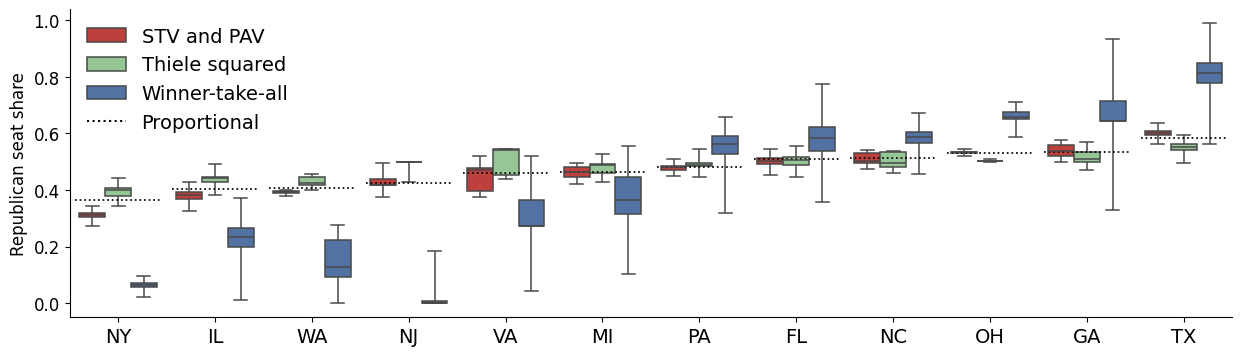

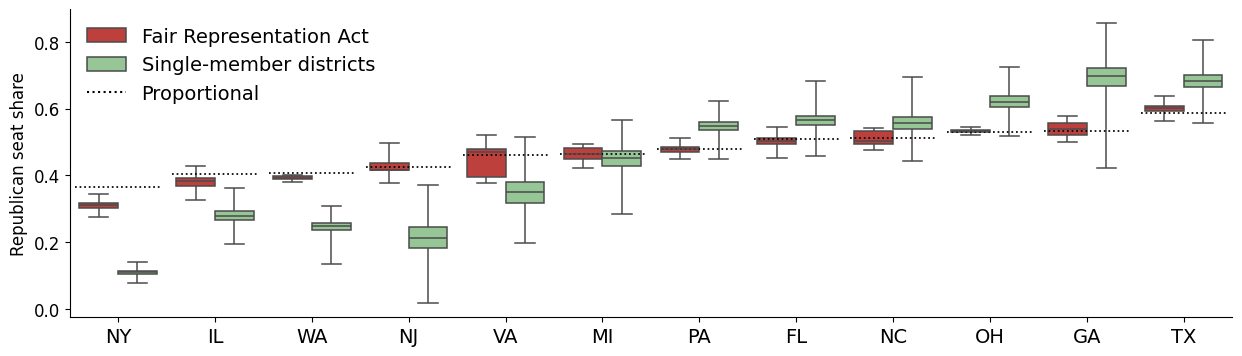

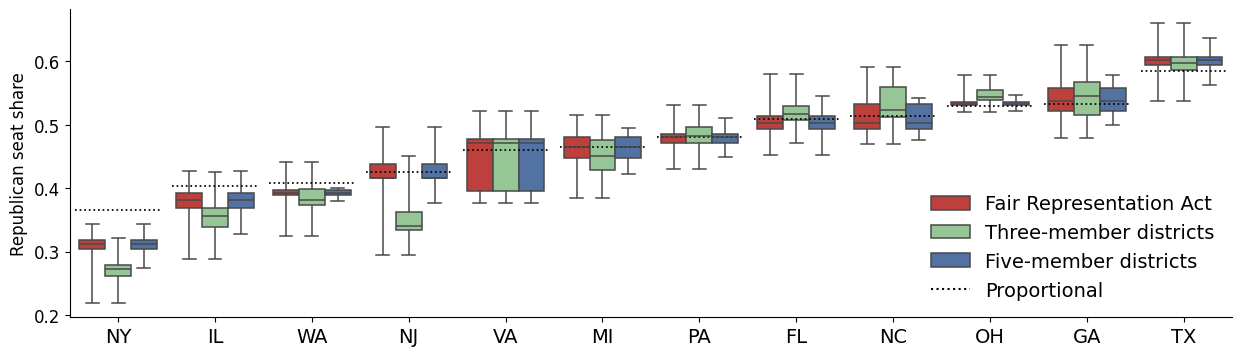

In [6]:
plot_hr4000(relabel_legend_entries(hr4000_df), str(OUTPUT_FIG9))
print(OUTPUT_FIG9)

fig4_df = relabel_legend_entries(
    create_hr4000_smd_baseline_distr_df(baseline_distributions, hr4000_df)
)
plot_hr4000(
    fig4_df,
    str(OUTPUT_FIG4),
)
print(OUTPUT_FIG4)

fig10_df = relabel_legend_entries(
    create_hr4000_mmd_baseline_distr_df(baseline_distributions, hr4000_df)
)
plot_hr4000(
    fig10_df,
    str(OUTPUT_FIG10),
)
print(OUTPUT_FIG10)
